<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Data Exploration & Pipeline Setup

Two goals for this phase:
1. **Explore** the dataset — understand its structure, distribution, and quirks
   before committing to design choices
2. **Build** a clean PyTorch data pipeline based on what we learn

EDA is genuinely useful here because the dataset was originally designed for object detection, but we're using it for classification. The mismatch means we have decisions to make (which classes? what minimum crop size? how to handle imbalance?) that should be informed by what's actually in the data, not assumed

In [1]:
# mount drive and import basics
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Mounted at /content/drive


In [2]:
# all paths in one place
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL') # Manually Uploaded
DATA_ROOT = DRIVE_ROOT / 'coco'

# image folders for each split
IMG_DIRS = {
    'train': DATA_ROOT / 'images' / 'train',
    'val':   DATA_ROOT / 'images' / 'val',
    'test':  DATA_ROOT / 'images' / 'test',
}
# annotation JSON files for each split
ANN_FILES = {
    'train': DATA_ROOT / 'annotations' / 'instances_train.json',
    'val':   DATA_ROOT / 'annotations' / 'instances_val.json',
    'test':  DATA_ROOT / 'annotations' / 'instances_test.json',
}

# checks everything exists
for split, p in IMG_DIRS.items():
    print(f'{split} images: {p.exists()} - {p}')
for split, p in ANN_FILES.items():
    print(f'{split} anns:   {p.exists()} - {p}')

train images: True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/images/train
val images: True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/images/val
test images: True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/images/test
train anns:   True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/annotations/instances_train.json
val anns:   True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/annotations/instances_val.json
test anns:   True - /content/drive/MyDrive/Colab Notebooks/AdvancedDL/coco/annotations/instances_test.json


## Approach A — Manual JSON parsing

Let's parse the annotations by hand to understand
the data structure. COCO JSON has 4 top-level keys: `images`, `annotations`,
`categories`, `info`.

This was understood after a back and ford using the read.me from the dataset. A suggestion was made of using a library pycocotools but I am first navigating a manual solution.

In [21]:
# load the train annotations manually with plain json
with open(ANN_FILES['train']) as f:
    coco_raw = json.load(f)

print('Top-level keys:', list(coco_raw.keys()))
print(f"Images:      {len(coco_raw['images'])}")
print(f"Annotations: {len(coco_raw['annotations'])}")
print(f"Categories:  {len(coco_raw['categories'])}")

# peek at one of each
print('\nExample image entry:')
print(coco_raw['images'][0])
print('\nExample annotation entry:')
print(coco_raw['annotations'][0])
print('\nExample category entry:')
print(coco_raw['categories'][0])

Top-level keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Images:      4363
Annotations: 53984
Categories:  25

Example image entry:
{'id': 1, 'file_name': 'warehouse_002370.png', 'width': 512, 'height': 512, 'date_captured': '', 'license': 1}

Example annotation entry:
{'id': 1, 'image_id': 1, 'category_id': 15, 'bbox': [0, 401.0, 217.0, 110.0], 'area': 23870.0, 'iscrowd': 0, 'segmentation': []}

Example category entry:
{'id': 1, 'name': 'box', 'supercategory': 'container'}


In [4]:
# build three lookup dictionaries for fast access by id

# image_id -> list of its annotations
# setdefault means "if the key doesn't exist, create it with value []"
img_id_to_anns = {}
for ann in coco_raw['annotations']:
    img_id_to_anns.setdefault(ann['image_id'], []).append(ann)

img_id_to_info = {img['id']: img for img in coco_raw['images']} # image_id -> full image info dict

cat_id_to_name = {c['id']: c['name'] for c in coco_raw['categories']} # category_id -> category name (like 7 -> 'pallet')

some_img_id = coco_raw['images'][0]['id']
print(f"Image id {some_img_id}:")
print(f"  file: {img_id_to_info[some_img_id]['file_name']}")
print(f"  num annotations: {len(img_id_to_anns.get(some_img_id, []))}")
print(f"  classes in image: {[cat_id_to_name[a['category_id']] for a in img_id_to_anns[some_img_id]]}")

Image id 1:
  file: warehouse_002370.png
  num annotations: 14
  classes in image: ['wall', 'ceiling', 'floor', 'rack', 'pillar', 'lamp', 'pallet', 'sign', 'wire', 'fuse_box', 'floor_decal', 'fire_extinguisher', 'box', 'paper_note']


### 1b — Same task with pycocotools

The official library wraps the same logic we just did manually.

In [6]:
# pycocotools is the standard library for reading COCO datasets
# Library : https://github.com/ppwwyyxx/cocoapi
# it does exactly what we did above (parse json, build lookup dicts) but wrapped in a class
from pycocotools.coco import COCO

# creates a COCO object, under the hood it reads the json and builds indexes
coco = COCO(str(ANN_FILES['train']))

# library methods instead of our own dicts
print(f'Num images:       {len(coco.getImgIds())}')
print(f'Num annotations:  {len(coco.getAnnIds())}')
print(f'Num categories:   {len(coco.getCatIds())}')

# same lookup as the manual version, but using library methods
some_img_id = coco.getImgIds()[0]
anns = coco.loadAnns(coco.getAnnIds(imgIds=[some_img_id]))
img_info = coco.loadImgs([some_img_id])[0]
print(f"\nImage id {some_img_id}:")
print(f"  file: {img_info['file_name']}")
print(f"  num annotations: {len(anns)}")
print(f"  classes: {[coco.loadCats(a['category_id'])[0]['name'] for a in anns]}")

loading annotations into memory...
Done (t=0.43s)
creating index...
index created!
Num images:       4363
Num annotations:  53984
Num categories:   25

Image id 1:
  file: warehouse_002370.png
  num annotations: 14
  classes: ['wall', 'ceiling', 'floor', 'rack', 'pillar', 'lamp', 'pallet', 'sign', 'wire', 'fuse_box', 'floor_decal', 'fire_extinguisher', 'box', 'paper_note']


### Decision: which approach to use going forward

Both work. pycocotools is less code and handles edge cases I'd otherwise hit myself.
The rest of the pipeline uses it. The manual version stays here as a reference for
when we (or the marker) want to see what the library is actually doing.

## Section 2: Dataset statistics

Now that we can read the annotations, we look at the actual contents. Class
distribution tells us about imbalance. Bounding box size distribution tells us
how much usable visual information we have per object.

In [22]:
# load all three splits as separate COCO objects
cocos = {split: COCO(str(ANN_FILES[split])) for split in ['train', 'val', 'test']}

# helper function: count how many annotations each class has
def class_counts(coco_obj):
    counts = Counter()
    for ann_id in coco_obj.getAnnIds():
        ann = coco_obj.loadAnns([ann_id])[0]
        name = coco_obj.loadCats(ann['category_id'])[0]['name']
        counts[name] += 1
    return counts

# compute counts for each split
counts_per_split = {split: class_counts(c) for split, c in cocos.items()}

# print the top 15 classes in train, and show how many samples each has in val and test too
print('Top 15 classes in train set:')
for name, n in counts_per_split['train'].most_common(15):
    val_n = counts_per_split['val'].get(name, 0)
    test_n = counts_per_split['test'].get(name, 0)
    print(f'  {name:20s}  train={n:5d}  val={val_n:5d}  test={test_n:5d}')

loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
loading annotations into memory...
Done (t=0.48s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Top 15 classes in train set:
  floor                 train= 4321  val=  926  test=  933
  wall                  train= 4313  val=  925  test=  924
  floor_decal           train= 4109  val=  876  test=  886
  sign                  train= 4077  val=  874  test=  888
  pillar                train= 4035  val=  850  test=  872
  box                   train= 3999  val=  857  test=  862
  pallet                train= 3948  val=  853  test=  860
  rack                  train= 3928  val=  838  test=  860
  bracket               train= 3380  val=  714  test=  702
  lamp                  train= 3042  val=  663  test=  672
  wire                  train= 2713  val=  594  test=  612
  ceiling               train= 2678  val=  570  test=  579
  fire_extingu

Bbox shorter side stats (pixels):
  min:    1.0
  median: 43.0
  mean:   57.3
  max:    344.0
  % of boxes with shorter side < 10px: 13.8%
  % of boxes with shorter side < 20px: 26.7%
  % of boxes with shorter side < 30px: 36.9%
  % of boxes with shorter side < 50px: 56.2%


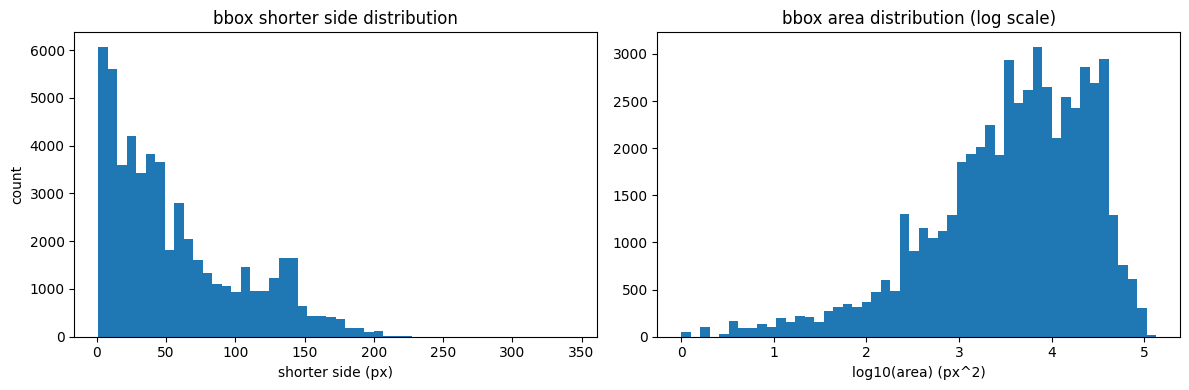

In [23]:
# look at how big the bounding boxes are -- small boxes can't be rescaled to 224x224 usefully
train_coco = cocos['train']
bbox_areas = []
bbox_sides = []

# collect area and shorter-side for every box in train
for ann_id in train_coco.getAnnIds():
    ann = train_coco.loadAnns([ann_id])[0]
    x, y, w, h = ann['bbox']
    bbox_areas.append(w * h)
    bbox_sides.append(min(w, h))  # shorter side is the limiting dimension

bbox_sides = np.array(bbox_sides)

# basic stats
print(f'Bbox shorter side stats (pixels):')
print(f'  min:    {bbox_sides.min():.1f}')
print(f'  median: {np.median(bbox_sides):.1f}')
print(f'  mean:   {bbox_sides.mean():.1f}')
print(f'  max:    {bbox_sides.max():.1f}')

# how many boxes fall below common thresholds?
for thresh in [10, 20, 30, 50]:
    pct = (bbox_sides < thresh).mean() * 100
    print(f'  % of boxes with shorter side < {thresh}px: {pct:.1f}%')

# plot distributions to see the shape visually
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(bbox_sides, bins=50)
ax[0].set_xlabel('shorter side (px)')
ax[0].set_ylabel('count')
ax[0].set_title('bbox shorter side distribution')
# area varies over several orders of magnitude, so log scale is clearer
ax[1].hist(np.log10(bbox_areas), bins=50)
ax[1].set_xlabel('log10(area) (px^2)')
ax[1].set_title('bbox area distribution (log scale)')
plt.tight_layout()
plt.show()

## Section 3: Visual sanity check

Numbers in tables can be wrong silently. Visualizing a sample image with its annotations is the cheapest way to confirm we understand the bounding box format and that labels match what's in the image.

This are the annotations from the dataset it self. Some boxes are noisy and that's what we will correct.

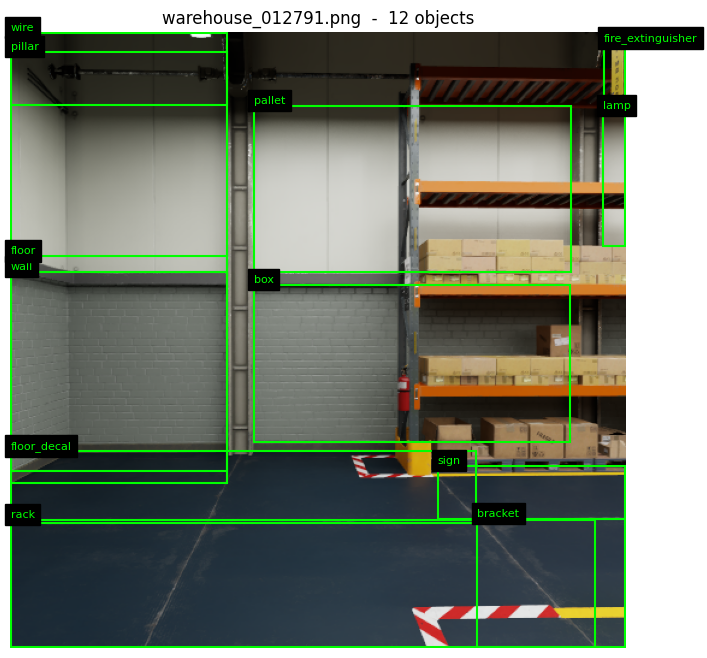

In [27]:
# pick a random training image and draw all its bounding boxes with labels
random.seed(12)
sample_img_id = random.choice(train_coco.getImgIds())
img_info = train_coco.loadImgs([sample_img_id])[0]
anns = train_coco.loadAnns(train_coco.getAnnIds(imgIds=[sample_img_id]))

# load the image file from disk
img_path = IMG_DIRS['train'] / img_info['file_name']
img = Image.open(img_path)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img)

# overlay each bounding box as a green rectangle with its class label
for ann in anns:
    x, y, w, h = ann['bbox']
    name = train_coco.loadCats(ann['category_id'])[0]['name']
    rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 2, name, color='lime', fontsize=8, backgroundcolor='black')

ax.set_title(f"{img_info['file_name']}  -  {len(anns)} objects")
ax.axis('off')
plt.show()

## Section 4: Decisions informed by exploration

Based on what the exploration showed, we now make three concrete choices:
- **All 25 classes**: matches the dataset spec; imbalance handled during training
- **Minimum bbox size of 20px**: drops boxes too small to be usable after resizing
- **Integer label mapping ordered by frequency**: class 0 is the most common



In [28]:
# use all 25 classes from the dataset
all_classes = [c['name'] for c in cocos['train'].loadCats(cocos['train'].getCatIds())]

# sort by train frequency so class index 0 is the most common class
# this makes the confusion matrix easier to read later
all_classes = [name for name, _ in counts_per_split['train'].most_common() if name in all_classes]

# print each class with its index and train count
print(f'Using all {len(all_classes)} classes:')
for i, name in enumerate(all_classes):
    count = counts_per_split['train'].get(name, 0)
    print(f'  {i}: {name:25s} (train count: {count})')

# sanity check: the four classes required for Part 3 embeddings must be in our list
required = {'floor', 'wall', 'pallet', 'sign'}
missing = required - set(all_classes)
print(f'\nRequired classes present: {required - missing}')

# build the class-to-index mappings used throughout training
CLASS_TO_IDX = {name: i for i, name in enumerate(all_classes)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(all_classes)

# filter threshold for unusable tiny crops
MIN_BOX_SIDE = 20

Using all 25 classes:
  0: floor                     (train count: 4321)
  1: wall                      (train count: 4313)
  2: floor_decal               (train count: 4109)
  3: sign                      (train count: 4077)
  4: pillar                    (train count: 4035)
  5: box                       (train count: 3999)
  6: pallet                    (train count: 3948)
  7: rack                      (train count: 3928)
  8: bracket                   (train count: 3380)
  9: lamp                      (train count: 3042)
  10: wire                      (train count: 2713)
  11: ceiling                   (train count: 2678)
  12: fire_extinguisher         (train count: 2224)
  13: paper_note                (train count: 1471)
  14: crate                     (train count: 888)
  15: barrel                    (train count: 847)
  16: fuse_box                  (train count: 783)
  17: barcode                   (train count: 770)
  18: bottle                    (train count: 470)
  19:

In [29]:
# for each split, flatten the dataset into a list of (image_path, bbox, label) entries
# each entry is one training sample -- one crop, one label

def build_samples(coco_obj, img_dir, class_to_idx, min_side):
    # local lookup, coco category id -> human-readable class name
    cat_id_to_name = {c['id']: c['name'] for c in coco_obj.loadCats(coco_obj.getCatIds())}
    samples = []

    # walk through every annotation in this split
    for ann_id in coco_obj.getAnnIds():
        ann = coco_obj.loadAnns([ann_id])[0]
        name = cat_id_to_name[ann['category_id']]

        # skip if class not in our selected set (redundant here since we use all 25, but future-proof)
        if name not in class_to_idx:
            continue

        # skip if the box is too small to be useful after resizing to 224x224
        x, y, w, h = ann['bbox']
        if min(w, h) < min_side:
            continue

        # get the source image path
        img_info = coco_obj.loadImgs([ann['image_id']])[0]
        img_path = img_dir / img_info['file_name']

        # store everything the Dataset class will need
        samples.append({
            'img_path': str(img_path),
            'bbox': [x, y, w, h],
            'label': class_to_idx[name],
            'class_name': name,
        })
    return samples

# build samples for all three splits
samples = {
    split: build_samples(cocos[split], IMG_DIRS[split], CLASS_TO_IDX, MIN_BOX_SIDE)
    for split in ['train', 'val', 'test']
}

# print per-class counts after filtering to see the final dataset size
for split, s in samples.items():
    label_counts = Counter(x['label'] for x in s)
    print(f'{split}: {len(s)} samples')
    for idx in range(NUM_CLASSES):
        print(f'  {IDX_TO_CLASS[idx]:20s}: {label_counts[idx]}')
    print()

train: 39592 samples
  floor               : 3270
  wall                : 2993
  floor_decal         : 3276
  sign                : 3177
  pillar              : 2933
  box                 : 3003
  pallet              : 3399
  rack                : 2801
  bracket             : 2714
  lamp                : 2243
  wire                : 1944
  ceiling             : 1979
  fire_extinguisher   : 1747
  paper_note          : 870
  crate               : 497
  barrel              : 349
  fuse_box            : 327
  barcode             : 606
  bottle              : 169
  cone                : 367
  emergency_board     : 305
  bucket              : 139
  cart                : 239
  paper_shortcut      : 123
  forklift            : 122

val: 8525 samples
  floor               : 710
  wall                : 668
  floor_decal         : 679
  sign                : 691
  pillar              : 616
  box                 : 660
  pallet              : 745
  rack                : 607
  bracket             :

## Section 5: Building the data pipeline

With our decisions made, we build the PyTorch Dataset class and verify it
produces correctly shaped, correctly normalized tensors that match the labels.

In [30]:
from torchvision import transforms

class WarehouseCropDataset(Dataset):
    """
    yields (cropped_image_tensor, label) for one bounding box at a time
    samples: list of dicts from build_samples()
    transform: torchvision transform pipeline to apply to each crop
    """

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        # tiny cache if consecutive samples come from the same image, reuse it
        self._img_cache = {}

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        # cache hit, same image as the last call
        if path in self._img_cache:
            return self._img_cache[path]
        # cache miss: open image from disk and replace the cache
        img = Image.open(path).convert('RGB')
        self._img_cache = {path: img}
        return img

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = self._load_image(s['img_path'])
        x, y, w, h = s['bbox']
        # PIL's crop takes (left, upper, right, lower) corners, not [x, y, w, h]
        crop = img.crop((x, y, x + w, y + h))
        if self.transform is not None:
            crop = self.transform(crop)
        return crop, s['label']


# imagenet normalization constants for our pretrained backbones expect these
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224  # standard input size for ResNet and ViT

# basic preprocessing pipeline: resize -> tensor -> normalize
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# instantiate the train dataset and check a sample
train_ds = WarehouseCropDataset(samples['train'], transform=basic_transform)
print(f'Train dataset length: {len(train_ds)}')
crop, label = train_ds[0]
print(f'First crop shape: {crop.shape}, label: {label} ({IDX_TO_CLASS[label]})')

Train dataset length: 39592
First crop shape: torch.Size([3, 224, 224]), label: 1 (wall)


Batch shape: torch.Size([16, 3, 224, 224]), labels: torch.Size([16])


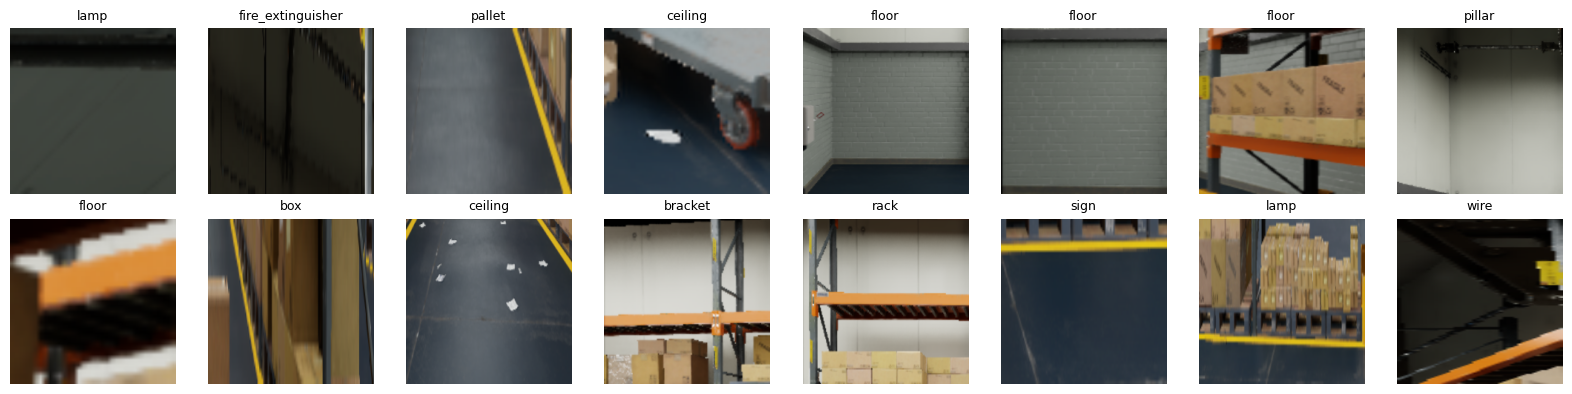

In [32]:
# DataLoader batches samples from the Dataset
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)

# grab one batch to verify shapes
batch_imgs, batch_labels = next(iter(train_loader))
print(f'Batch shape: {batch_imgs.shape}, labels: {batch_labels.shape}')

# helper to undo the imagenet normalization so we can display images normally
def unnormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

# display the 16 crops with their labels
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    # permute because torch uses (C, H, W) but matplotlib wants (H, W, C)
    img = unnormalize(batch_imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[batch_labels[i].item()], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

What we have:
- Data loaded and explored across all three splits
- 25 classes
- Minimum bbox size filter at 20px
- `WarehouseCropDataset` class producing normalized 224x224 crops + labels
- DataLoader verified to produce sensible batches

Next are the experiments.
